## Homework 7: Clustering & PCA with High-Dimensional Data
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
    
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Part 1: Initial Clustering

In [5]:
data_bundle = load_breast_cancer()
X = pd.DataFrame(data_bundle.data, columns=data_bundle.feature_names)
y = data_bundle.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"DBSCAN Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.3f}")

K-Means Silhouette Score: 0.345
DBSCAN Silhouette Score: 0.481


Part 2: Dimensionality Reduction (PCA)

The Top 3 Contributors to Principal Component 1 (PC1)

* mean concave points: Measures the number of concave portions of the cell nuclei contour

* mean concavity: Severity of concave portions of the contour.

* mean compactness: Combined measure of perimeter and area (perimeter^2/area - 1.0).
 

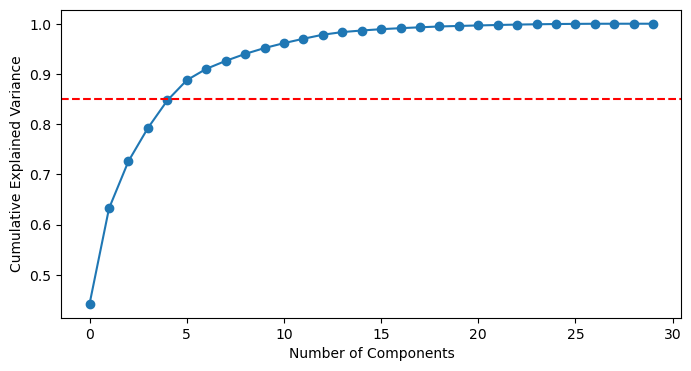

Number of PC's for 85% variance: 6
Top 3 contributors to PC1:
                           PC1
mean concave points   0.260854
mean concavity        0.258400
worst concave points  0.250886


In [6]:
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np

pca = PCA()
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle='--')
plt.show()

n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.85) + 1
print(f"Number of PC's for 85% variance: {n_components}")

loadings = pd.DataFrame(pca.components_[0], index=X.columns, columns=['PC1'])
top_3_features = loadings.abs().sort_values(by='PC1', ascending=False).head(3)
print("Top 3 contributors to PC1:")
print(top_3_features)

Part 3: Clustering Using Principal Components

Reducing the 30 original features to just 6 Principal components allows the models to focus on the most significant patterns. The K-Means Silhouette Score increase after PCA because the clusters became more distinct in space. This results in more confident and accurate groupsings than using the full, complex dataset.

In [7]:
X_pca = pca_data[:, :n_components]

kmeans_pca = KMeans(n_clusters=2, random_state=42)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

dbscan_pca = DBSCAN(eps=3, min_samples=5) 
dbscan_pca_labels = dbscan_pca.fit_predict(X_pca)

print(f"PCA K-means Silhouette: {silhouette_score(X_pca, kmeans_pca_labels):.3f}")

PCA K-means Silhouette: 0.377


Part 4: Visual Validation

The unsupervised K-Means cluster matched the actual medical diagnosis very well. Both the algorithm and the real-world labels show a clear separation along the PC1 axis, which represents key markers like cell concavity and irregularity. This confirms that the program successfully identified the primary biological differences between malignant and benign samples without any prior instruction.

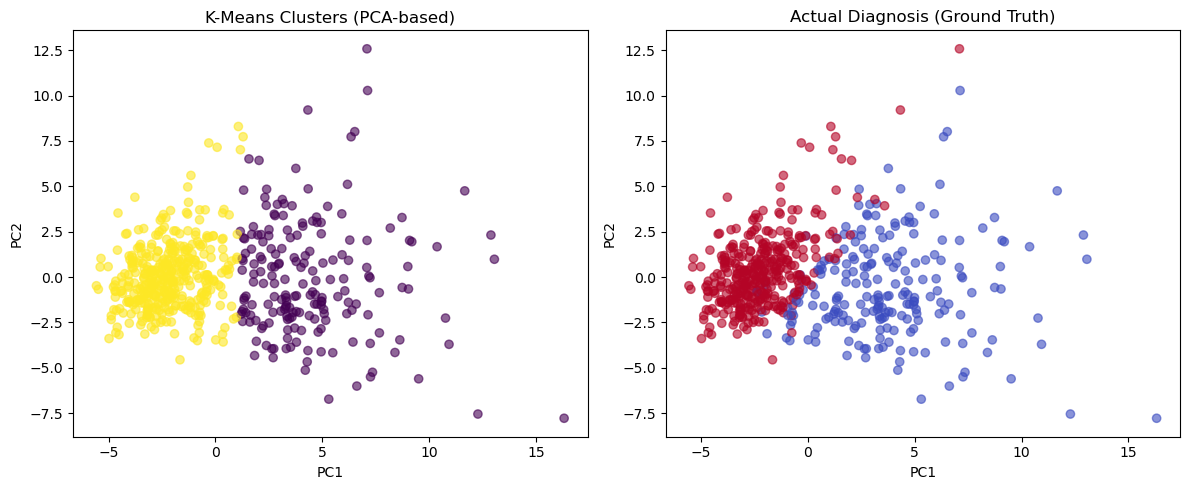

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans_pca_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clusters (PCA-based)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Actual Diagnosis (Ground Truth)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()